图表已生成并保存：D:\python\敏感性分析\第二部分\柱状图.png


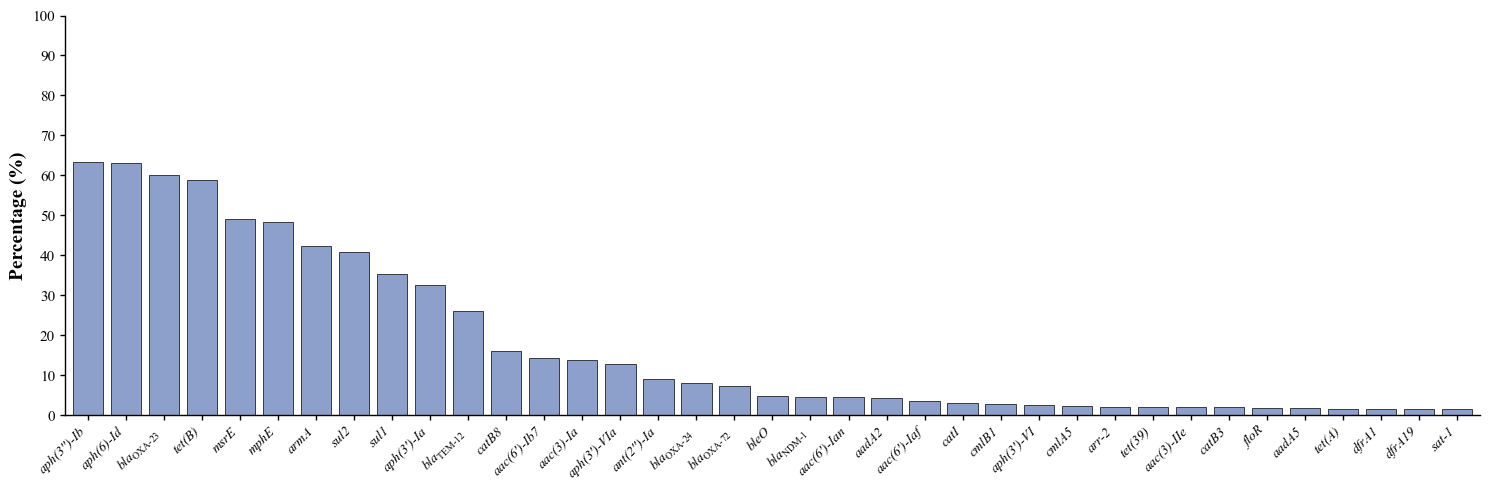

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. 全局字体设置
# ============================================================

# 所有普通文字使用 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 数学公式中的字体也使用 Times New Roman
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
plt.rcParams["mathtext.it"] = "Times New Roman:italic"
plt.rcParams["mathtext.bf"] = "Times New Roman:bold"

plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 2. 输入输出文件
# ============================================================

input_file = r"D:\A.baumannii\data\gene_bar_chart.csv"

output_file = "bar_chart.png"


# ============================================================
# 3. 读取数据
# ============================================================

try:
    df = pd.read_csv(input_file)

except FileNotFoundError:
    print(f"错误：找不到文件：{input_file}")
    raise


# ============================================================
# 4. 确定列
#
# 推荐文件结构：
#
# Gene    Total_Count    Percentage
# sul1    10000          25.0
# ...
# ============================================================

if {
    "Gene",
    "Total_Count",
    "Percentage"
}.issubset(df.columns):

    gene_col = "Gene"
    percent_col = "Percentage"

else:
    # 如果列名不同：
    # 第一列作为基因名称
    # 第三列作为 Percentage
    gene_col = df.columns[0]
    percent_col = df.columns[2]


# ============================================================
# 5. 数据清理
# ============================================================

df[gene_col] = (
    df[gene_col]
    .astype(str)
    .str.strip()
)

df[percent_col] = pd.to_numeric(
    df[percent_col],
    errors="coerce"
)

df = df.dropna(
    subset=[
        gene_col,
        percent_col
    ]
)


# ============================================================
# 6. 使用文件中的全部基因
# ============================================================

plot_df = df.copy()


# ============================================================
# 7. 按百分比从高到低排序
# ============================================================

plot_df = (
    plot_df
    .sort_values(
        by=percent_col,
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 8. bla 基因中使用的短横杠
#
# 普通 "-" 在数学模式中容易显示得太长。
#
# 这里使用 Unicode U+2010 短连字符：
#
# ‐
# ============================================================

SHORT_HYPHEN = "‐"


# ============================================================
# 9. 格式化标签
#
# 规则：
#
# 1）普通基因：
#
# sul1
# catB8
# aph(3')-Id
# ant(2'')-Id
#
# 不进入数学公式环境。
#
# 后面直接把整个 tick label 设置成
# Times New Roman italic。
#
# 这样：
#
# aph(3')-Id
#
# 中的 ' 会留在括号中，
# 不会变成上标 prime。
#
#
# 2）bla 基因：
#
# blaOXA-24
#
# bla       -> 斜体
# OXA‐24    -> 正体下标
# ============================================================

def format_gene_label(gene):

    gene = str(gene).strip()

    # --------------------------------------------------------
    # bla 开头
    # --------------------------------------------------------

    if gene.lower().startswith("bla"):

        suffix = gene[3:]

        # 换成短横杠
        suffix = suffix.replace(
            "-",
            SHORT_HYPHEN
        )

        # bla 为斜体
        # 后面的亚型为正体下标
        return (
            rf"$\mathit{{bla}}_"
            rf"{{\mathrm{{{suffix}}}}}$"
        )

    # --------------------------------------------------------
    # 其他基因保持普通文本
    #
    # 例如：
    # aph(3')-Id
    # ant(2'')-Id
    #
    # 不使用 mathtext！
    # --------------------------------------------------------

    return gene


# ============================================================
# 10. 生成格式化标签
# ============================================================

formatted_labels = [
    format_gene_label(gene)
    for gene in plot_df[gene_col]
]


# ============================================================
# 11. X轴位置
# ============================================================

x_positions = list(
    range(len(plot_df))
)


# ============================================================
# 12. 创建画布
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 5)
)


# ============================================================
# 13. 绘制柱状图
# ============================================================

bars = ax.bar(

    x_positions,

    plot_df[percent_col],

    color="#8da0cb",

    edgecolor="black",

    linewidth=0.5,

    width=0.8
)


# ============================================================
# 14. Y轴标题
# ============================================================

ax.set_ylabel(

    "Percentage (%)",

    fontsize=14,

    fontweight="bold",

    fontfamily="Times New Roman"
)


# ============================================================
# 15. Y轴范围
# ============================================================

ax.set_ylim(
    0,
    100
)


# ============================================================
# 16. Y轴刻度
# ============================================================

ax.set_yticks(
    range(
        0,
        101,
        10
    )
)

for label in ax.get_yticklabels():

    label.set_fontfamily(
        "Times New Roman"
    )

    label.set_fontsize(
        11
    )


# ============================================================
# 17. 设置 X 轴刻度位置
# ============================================================

ax.set_xticks(
    x_positions
)


# ============================================================
# 18. 设置 X 轴标签
# ============================================================

ax.set_xticklabels(

    formatted_labels,

    rotation=45,

    ha="right",

    fontsize=10
)


# ============================================================
# 19. 分别设置每个 X 轴标签字体
#
# 非 bla 基因：
# 整个名称 Times New Roman italic
#
# bla 基因：
# 不再强制整个标签 italic，
# 因为 mathtext 中已经分别规定：
#
# bla = italic
# 亚型 = roman
# ============================================================

for tick_label, gene in zip(
    ax.get_xticklabels(),
    plot_df[gene_col]
):

    gene = str(gene).strip()

    # 全部统一 Times New Roman
    tick_label.set_fontfamily(
        "Times New Roman"
    )

    # --------------------------------------------------------
    # 普通基因整体斜体
    #
    # 这里是普通文本，因此：
    #
    # aph(3')-Id
    #
    # 的 ' 不会跑到上面
    # --------------------------------------------------------

    if not gene.lower().startswith("bla"):

        tick_label.set_fontstyle(
            "italic"
        )

    # --------------------------------------------------------
    # bla 基因不再给整个 label 设置 italic
    #
    # 否则会影响后面的正体亚型
    # --------------------------------------------------------

    else:

        tick_label.set_fontstyle(
            "normal"
        )


# ============================================================
# 20. X轴范围
# ============================================================

ax.set_xlim(
    -0.6,
    len(plot_df) - 0.4
)


# ============================================================
# 21. 去掉上方和右侧边框
# ============================================================

ax.spines["top"].set_visible(
    False
)

ax.spines["right"].set_visible(
    False
)


# ============================================================
# 22. 左边框和下边框线宽
# ============================================================

ax.spines["left"].set_linewidth(
    1
)

ax.spines["bottom"].set_linewidth(
    1
)


# ============================================================
# 23. 坐标轴刻度样式
# ============================================================

ax.tick_params(

    axis="both",

    direction="out",

    width=1
)


# ============================================================
# 24. 自动布局
# ============================================================

plt.tight_layout()


# ============================================================
# 25. 保存图片
# ============================================================

plt.savefig(

    output_file,

    dpi=600,

    bbox_inches="tight"
)


# ============================================================
# 26. 输出提示
# ============================================================

print(
    f"图表已生成并保存：{output_file}"
)


# ============================================================
# 27. 显示
# ============================================================

plt.show()